In [2]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron
from matplotlib.colors import ListedColormap

# Part I – Importing the Dataset and Select Versicolor and Virginica (3 pts.)

### 1.) Import the Iris data

In [3]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/'        
                 'machine-learning-databases/iris/iris.data', header=None)
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### 2.) From the data set select versicolor and virginica. 

In [4]:
df = df.rename(columns={0:"sepal_length", 1:"sepal_width", 2:"petal_length", 3:"petal_width", 4: 'species'})
df = df.query('species == "Iris-versicolor" | species == "Iris-virginica"')
df = df.reset_index()
df = df.drop("index", axis=1)

print(df)

    sepal_length  sepal_width  petal_length  petal_width          species
0            7.0          3.2           4.7          1.4  Iris-versicolor
1            6.4          3.2           4.5          1.5  Iris-versicolor
2            6.9          3.1           4.9          1.5  Iris-versicolor
3            5.5          2.3           4.0          1.3  Iris-versicolor
4            6.5          2.8           4.6          1.5  Iris-versicolor
..           ...          ...           ...          ...              ...
95           6.7          3.0           5.2          2.3   Iris-virginica
96           6.3          2.5           5.0          1.9   Iris-virginica
97           6.5          3.0           5.2          2.0   Iris-virginica
98           6.2          3.4           5.4          2.3   Iris-virginica
99           5.9          3.0           5.1          1.8   Iris-virginica

[100 rows x 5 columns]


### 3.) Use the petal length and petal width as features

In [5]:
df = df.drop("sepal_length", axis=1)
df = df.drop("sepal_width", axis=1)
df.species = np.where(df.species == 'Iris-versicolor', 0,1)
print(df)

    petal_length  petal_width  species
0            4.7          1.4        0
1            4.5          1.5        0
2            4.9          1.5        0
3            4.0          1.3        0
4            4.6          1.5        0
..           ...          ...      ...
95           5.2          2.3        1
96           5.0          1.9        1
97           5.2          2.0        1
98           5.4          2.3        1
99           5.1          1.8        1

[100 rows x 3 columns]


# Part II – Training the Logistic Regression Model  (5 pts.)

### 1. Split the dataset to training data and test set with 30% test size and random state=1.



In [6]:
y = df.species
X = df.drop("species", axis=1)
#y = np.where( species == 'Iris-versicolor' ,0,1)

# splitting data set with 30% test size and random state 1 for reproducibility
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=1, stratify=y)

#print("X data type\n\n",X.dtypes,"\n\ny data type\n\n", y.dtypes)
#print("length of X_train:",len(X_train),"\nlength of X_test:", len(X_test),"\nlength of y_train:", len(y_train),"\nlength of y_test:", len(y_test))
print("array X(training data set) has the values:\n\n",X,"\n\narray y(class label) has the values:\n\n", y)


array X(training data set) has the values:

     petal_length  petal_width
0            4.7          1.4
1            4.5          1.5
2            4.9          1.5
3            4.0          1.3
4            4.6          1.5
..           ...          ...
95           5.2          2.3
96           5.0          1.9
97           5.2          2.0
98           5.4          2.3
99           5.1          1.8

[100 rows x 2 columns] 

array y(class label) has the values:

 0     0
1     0
2     0
3     0
4     0
     ..
95    1
96    1
97    1
98    1
99    1
Name: species, Length: 100, dtype: int32


### 2. Implement the feature scaling method.



In [8]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

print(y_train)
#print(X_train_std)

10    0
51    1
19    0
4     0
38    0
     ..
29    0
17    0
40    0
52    1
48    0
Name: species, Length: 70, dtype: int32


### 3. Train the Logistic Regression Model by fitting the train data set using the LogisticRegression class and as well the familiar fit method from the linear_module with inverse regularization parameter 𝐶=100 and random_state=1

In [13]:
lr = LogisticRegression(C=100.0, random_state=1)
lr.fit(X_train_std, y_train)

LogisticRegression(C=100.0, random_state=1)

# Part III – Evaluate the Logistic Regression Model  (10 pts.)

### 1. Count the number of misclassified samples.



In [276]:
y_pred = lr.predict(X_test_std)
print('Misclassified samples: %d' % (y_test != y_pred).sum())
print

Misclassified samples: 1


### 2. Determine which samples are misclassified.



In [277]:
print(y_test != y_pred)
pred_array2 = (y_test != y_pred)
# the one true value printed shows the missclassified sample

50    False
98    False
12    False
9     False
37    False
62    False
76    False
65    False
47    False
25    False
56     True
94    False
74    False
6     False
71    False
54    False
5     False
68    False
1     False
16    False
15    False
7     False
11    False
75    False
57    False
0     False
8     False
53    False
66    False
43    False
Name: species, dtype: bool


sample 56 is misclassified

### 3. Compare the predicted value and target value for the misclassified samples.



In [283]:
dg = pd.DataFrame(y_pred)
dg = dg.assign(y_test = pd.Series(y_test).values)
dg = dg.rename(columns={0:"y_pred", 1:"y_test"})
print(dg)

    y_pred  y_test
0        1       1
1        1       1
2        0       0
3        0       0
4        0       0
5        1       1
6        1       1
7        1       1
8        0       0
9        0       0
10       0       1
11       1       1
12       1       1
13       0       0
14       1       1
15       1       1
16       0       0
17       1       1
18       0       0
19       0       0
20       0       0
21       0       0
22       0       0
23       1       1
24       1       1
25       0       0
26       0       0
27       1       1
28       1       1
29       0       0


we see in row(10) that the y_pred value is not equal to the predicted value

### 4. Print the probabilities that misclassified samples belong to a certain class using the predict_proba method. Do the highest probabilities of the misclassified samples correspond to the predicted class labels?



In [284]:
pred_array = lr.predict_proba(X_test_std[:, :])
dg = dg.assign(probability_of_0 = pd.Series(pred_array[:,0]).values)
dg = dg.assign(probability_of_1 = pd.Series(pred_array[:,1]).values)
dg = dg.assign(missclassified = pd.Series(pred_array2).values)
print(dg)

# the false here means that it is not misclassified

    y_pred  y_test  probability_of_0  probability_of_1  missclassified
0        1       1      6.825747e-08      9.999999e-01           False
1        1       1      6.461916e-05      9.999354e-01           False
2        0       0      9.999989e-01      1.135134e-06           False
3        0       0      9.999835e-01      1.651213e-05           False
4        0       0      9.995247e-01      4.753368e-04           False
5        1       1      1.612430e-04      9.998388e-01           False
6        1       1      4.626700e-01      5.373300e-01           False
7        1       1      1.509258e-04      9.998491e-01           False
8        0       0      9.997964e-01      2.035541e-04           False
9        0       0      9.988531e-01      1.146860e-03           False
10       0       1      9.636286e-01      3.637138e-02            True
11       1       1      8.698989e-07      9.999991e-01           False
12       1       1      2.955690e-05      9.999704e-01           False
13    

Do the highest probabilities of the misclassified samples correspond to the predicted class labels?

Yes, the highest probability of the misclassified samples corresponded to the predicted class label, as seen on row 10 of the table. However, we note that the predicted class label is missclassified for that sample

### 5. Print the accuracy of the Logistic Regression model.

In [287]:
from sklearn.metrics import accuracy_score

print('Accuracy: %.2f' % accuracy_score(y_test, y_pred))
print('Accuracy: %.2f' % lr.score(X_test_std, y_test))

Accuracy: 0.97
Accuracy: 0.97


# Part IV – Plotting the decision regions and the Data  (15 pts.)

### 1. Plot the different decision regions using Matplot. Set the petal length as the x-axis and the petal width as the y-axis ~done

### 2. Visualize how well the decision regions separate the different samples in the plot. Use different colors and markers for the different class labels for the scatter plot of the samples. ~ done

### 3. Highlight the test samples by encircling them with black color. ~ done

### 4. Highlight the misclassified samples by encircling them with red color. ~ done

### 5. Put a legend that labels the class types of the different shapes in the scatter plot. ~ done


<ipython-input-23-98454bf634ed>:30: MatplotlibDeprecationWarning: Using a string of single character colors as a color sequence is deprecated since 3.2 and will be removed two minor releases later. Use an explicit list instead.
  plt.scatter(X_test[:, 0], X_test[:, 1], c='', edgecolor='black', alpha=1.0,
<ipython-input-23-98454bf634ed>:34: MatplotlibDeprecationWarning: Using a string of single character colors as a color sequence is deprecated since 3.2 and will be removed two minor releases later. Use an explicit list instead.
  plt.scatter(X_test[9, 0], X_test[9, 1], c='', edgecolor='red', alpha=1.0,


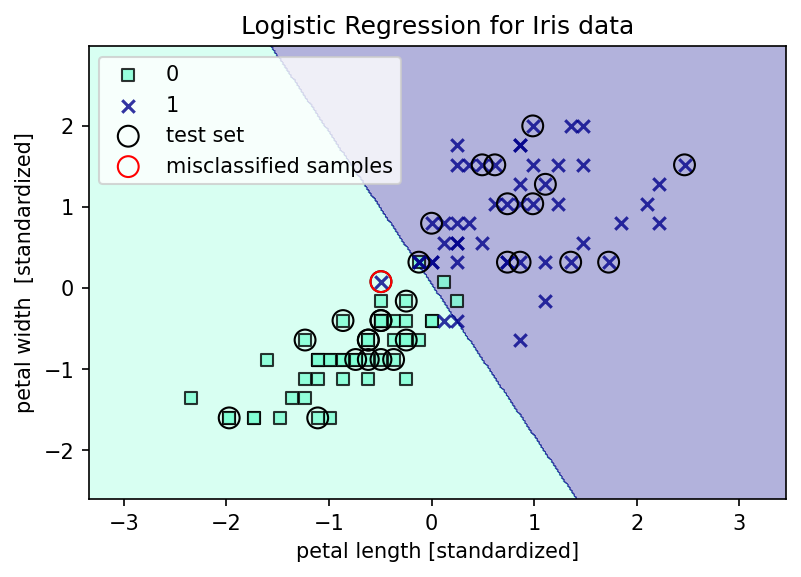

In [23]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('aquamarine', 'darkblue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.title('Logistic Regression for Iris data')
    
    #highlight test samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8, c=colors[idx],
                    marker=markers[idx], label=cl, edgecolor='black')
        
    # highlight test samples - emphasize test samples
    if test_idx:
        # plot all samples
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1], c='', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o', s=100, label='test set')
    
        # highlighting the missclassified sample
        plt.scatter(X_test[9, 0], X_test[9, 1], c='', edgecolor='red', alpha=1.0,
                   linewidth=1, marker='o', s=100, label='misclassified samples')


X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))  

plt.rcParams['figure.dpi'] = 150
plot_decision_regions(X=X_combined_std, y=y_combined, classifier=lr, test_idx=range(71,99))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width  [standardized]')
plt.legend(loc = 'upper left')
plt.show()